<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 3 — Filtros FIR, IIR y Transformada Z</font></h1>
<br>
<br>
<div style="text-align:right">
<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>
<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Nivel: 7.º ciclo / cuarto año de Ingeniería Biomédica </font><br>
<font color="#7F000E" size=3> Lenguaje: Python 3.x | Entorno: Jupyter Notebook / VS Code </font><br>
</div>

---

### **Objetivo**

El objetivo de este laboratorio no es memorizar funciones de Python. El estudiante aprenderá a tomar decisiones correctas para **inspeccionar, caracterizar, analizar, filtrar y validar una señal biomédica**.

**Flujo de trabajo:**

> Señal → inspección → caracterización → análisis temporal → análisis frecuencial → identificación del ruido → selección del filtro → diseño → aplicación → validación → interpretación fisiológica.

> **Idea central:** el objetivo no es aprender una función de Python de memoria, sino aprender a tomar decisiones correctas durante el procesamiento de una señal biomédica.

## 1. Objetivos de aprendizaje

Al finalizar el laboratorio, el estudiante será capaz de:

1. Analizar una señal biomédica en el dominio temporal.
2. Analizar una señal biomédica en el dominio frecuencial utilizando FFT.
3. Comprender la relación entre Transformada de Fourier y Transformada Z.
4. Diseñar y aplicar filtros FIR e IIR.
5. Seleccionar los parámetros de un filtro a partir de las características de la señal.
6. Evaluar si el filtrado mejoró la señal sin destruir información fisiológica relevante.

## 2. Entorno computacional

Se utilizarán:

- Python 3.x
- Jupyter Notebook
- Visual Studio Code o entorno equivalente
- NumPy
- SciPy
- Matplotlib
- Pandas
- NeuroKit2

### Instalación recomendada con UV

Desde una terminal:

```bash
uv venv
```

Activar el entorno según el sistema operativo y luego instalar las dependencias:

```bash
uv pip install numpy scipy matplotlib pandas neurokit2 jupyter
```

Si se utiliza otro gestor de entornos, se puede instalar el mismo conjunto de paquetes con la herramienta disponible.

## 3. Fundamentos teóricos

### 3.1 Señal discreta

Una señal discreta puede representarse como:

$$x[n]$$

donde $n$ representa el índice de muestra. Si la frecuencia de muestreo es $f_s$, el periodo de muestreo es:

$$T_s = \frac{1}{f_s}$$

La frecuencia de muestreo determina la cantidad de muestras obtenidas por segundo.

### 3.2 Transformada de Fourier

La señal puede estudiarse en dos dominios:

- **Temporal:** permite observar cómo cambia la amplitud con el tiempo.
- **Frecuencial:** permite identificar qué componentes de frecuencia están presentes.

La DFT se expresa como:

$$X[k] = \sum_{n=0}^{N-1} x[n]e^{-j2\pi kn/N}$$

La FFT es un algoritmo eficiente para calcular la DFT.

Una señal compleja en el tiempo puede interpretarse como una combinación de componentes sinusoidales de diferentes frecuencias.

### 3.3 Transformada Z

La Transformada Z se define, de manera general, como:

$$X(z)=\sum_{n=-\infty}^{\infty}x[n]z^{-n}$$

La variable $z$ es compleja. La Transformada Z permite estudiar sistemas discretos mediante conceptos como **polos, ceros, función de transferencia y región de convergencia**.

Para un sistema:

$$H(z)=\frac{Y(z)}{X(z)}=\frac{B(z)}{A(z)}$$

### 3.4 Relación Fourier–Z

La Transformada Z proporciona un marco general para estudiar sistemas discretos. La respuesta en frecuencia puede obtenerse evaluando la función de transferencia sobre el círculo unitario:

$$z=e^{j\omega}$$

Por tanto:

> **Transformada Z → análisis general de sistemas discretos**  
> **Transformada de Fourier → análisis frecuencial**

### 3.5 Filtros FIR

Un filtro FIR (Finite Impulse Response) puede expresarse mediante:

$$y[n]=\sum_{k=0}^{M}b[k]x[n-k]$$

No utiliza realimentación. Sus coeficientes determinan la respuesta del filtro. Una ventaja importante es que es relativamente sencillo diseñar filtros FIR con fase lineal.

### 3.6 Filtros IIR

Un filtro IIR (Infinite Impulse Response) utiliza realimentación. Conceptualmente:

$$H(z)=\frac{B(z)}{A(z)}$$

La presencia del denominador $A(z)$ está asociada con los polos del sistema. Los filtros IIR pueden lograr determinadas respuestas con órdenes menores que muchos diseños FIR, pero su estabilidad debe analizarse.

## 4. Herramientas y señal ECG

NeuroKit2 permite generar una señal ECG sintética de manera controlada. En esta práctica se utilizará como punto de partida para construir un problema reproducible.

Parámetros de ejemplo:

- duración = 10 s
- frecuencia de muestreo = 250 Hz
- frecuencia cardíaca = 70 bpm

In [ ]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 41.0 MB/s eta 0:00:00


In [ ]:
!uv pip install numpy scipy matplotlib pandas neurokit2 jupyter


Using Python 3.13.15 environment at: /usr
Resolved 113 packages in 678ms
Prepared 9 packages in 460ms
Installed 9 packages in 123ms
 + async-lru==2.3.0
 + jedi==0.20.0
 + json5==0.15.0
 + jupyter==1.1.1
 + jupyter-builder==1.2.2
 + jupyter-lsp==2.3.1
 + jupyterlab==4.6.3
 + jupyterlab-server==2.28.0
 + neurokit2==0.2.13


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
import neurokit2 as nk

print("Bibliotecas cargadas correctamente.")

Bibliotecas cargadas correctamente.


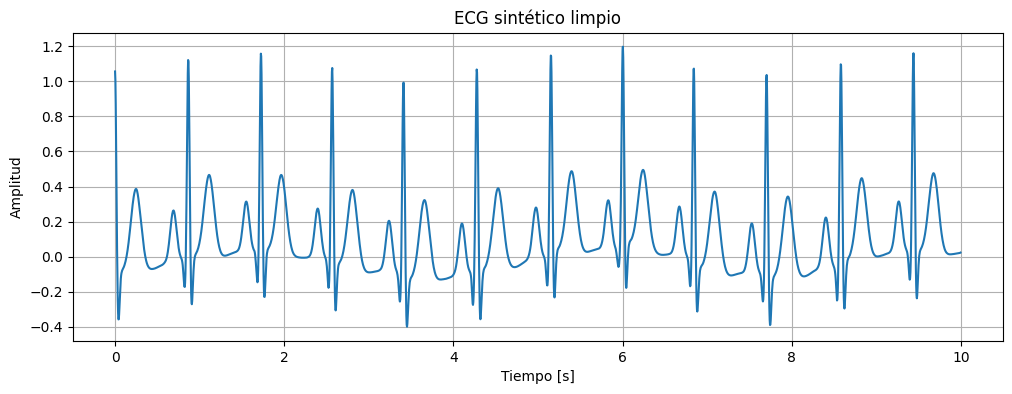

In [ ]:
# Generación de una señal ECG sintética
duration = 10
sampling_rate = 250
heart_rate = 70

ecg_clean = nk.ecg_simulate(
    duration=duration,
    sampling_rate=sampling_rate,
    heart_rate=heart_rate
)

t = np.arange(len(ecg_clean)) / sampling_rate

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_clean)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG sintético limpio")
plt.grid(True)
plt.show()

### Actividad inicial

Antes de continuar, responde:

1. ¿Cuál es la frecuencia de muestreo?
2. ¿Cuántas muestras contiene la señal?
3. ¿Cuál es su duración?
4. ¿Qué elementos de la morfología ECG puedes reconocer?
5. ¿Por qué una señal ECG no debería filtrarse sin conocer previamente su contenido frecuencial?

In [ ]:
# Respuesta - Actividad inicial (cálculo de las características básicas de la señal)
print(f"Frecuencia de muestreo (fs): {sampling_rate} Hz")
print(f"Número de muestras (N): {len(ecg_clean)}")
print(f"Duración: {len(ecg_clean)/sampling_rate:.2f} s")

### Respuesta — Actividad inicial

1.   La frecuencia de muestreo es de 250 Hz
2.   Al multiplicar la duración de la señal por la frecuencia de muestreo, se obtiene la cantidad de muestras, que es de 2500
3.   La duración de la señal es de 10 segundos
4.   Se define claramente en la mayor porción de la señal el complejo QRS, y las ondas P y T
5.   No hay que filtrar a ciegas el contenido frecuencial, porque fácilmente se puede perder ondas importantes que marcan la morfología clásica de la señal ECG al confundirlas con ruido




# EJERCICIO 1 — ANÁLISIS Y CARACTERIZACIÓN DE LA SEÑAL

## Competencia

Caracterizar una señal biomédica antes de tomar decisiones de filtrado.

En una aplicación real, la señal puede provenir de un archivo:

```text
senal_biomedica.wav
```

Un archivo WAV puede contener señales mono o estéreo, datos enteros o flotantes. Por ello, antes de procesarlo debes inspeccionar su formato.

### Si recibes un WAV

Utiliza:

```python
from scipy.io import wavfile
fs, data = wavfile.read("senal_biomedica.wav")
```

**No asumas** el tipo de dato, número de canales ni frecuencia de muestreo.

In [ ]:
# Plantilla para inspeccionar un archivo WAV.
# Completa los elementos indicados.

# fs, data = wavfile.read("senal_biomedica.wav")

# print("Frecuencia de muestreo:", ...)
# print("Número de muestras:", ...)
# print("Shape:", ...)
# print("Tipo de dato:", ...)
# print("Duración [s]:", ...)

In [ ]:
# Respuesta - Inspección robusta de un archivo WAV (o señal ECG como respaldo)
import os

#wav_path = "senal_biomedica.wav"
wav_path = "Laboratorios_Lab_02_ecg_record_111_channel_1.wav"

if os.path.exists(wav_path):
    fs_wav, data_wav = wavfile.read(wav_path)
    data_wav = np.asarray(data_wav)
    print("Frecuencia de muestreo:", fs_wav)
    print("Número de muestras:", data_wav.shape[0])
    print("Shape:", data_wav.shape)
    print("Tipo de dato:", data_wav.dtype)
    print("Duración [s]:", data_wav.shape[0] / fs_wav)
    if data_wav.ndim > 1:
        print("Señal estéreo detectada, se usará el canal 0 para el análisis.")
        data_wav = data_wav[:, 0]
    x_signal = data_wav.astype(float)
    fs = fs_wav
else:
    print("No se encontró 'senal_biomedica.wav'; se utilizará la señal ECG sintética como respaldo.")
    x_signal = np.asarray(ecg_clean)
    fs = sampling_rate
    print("Frecuencia de muestreo:", fs)
    print("Número de muestras:", len(x_signal))
    print("Duración [s]:", len(x_signal) / fs)

Frecuencia de muestreo: 360
Número de muestras: 3600
Shape: (3600,)
Tipo de dato: int16
Duración [s]: 10.0


### Trabajo solicitado

1. Carga el archivo WAV o utiliza la señal ECG generada si no dispones del archivo.
2. Identifica la frecuencia de muestreo.
3. Obtén el número de muestras.
4. Calcula la duración.
5. Grafica la señal en el dominio temporal.
6. Calcula la FFT.
7. Grafica el espectro de magnitud.
8. Identifica las principales componentes frecuenciales.
9. Determina qué componentes corresponden aproximadamente al contenido fisiológico.
10. Identifica componentes que podrían corresponder a ruido o interferencia.

### Completa el siguiente esquema

```python
fs = ...

N = ...

frequencies = ...

fft_signal = ...

magnitude = ...
```

No copies una solución. Completa cada variable justificando qué representa.

Frecuencia de muestreo: 250 Hz
Número de muestras: 2500
Duración: 10.00 s


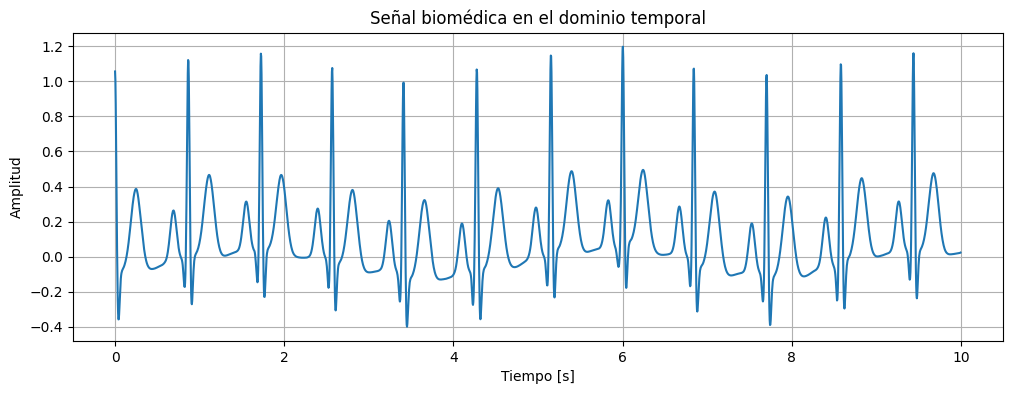

In [ ]:
# Análisis temporal: completa o adapta este bloque.
fs = sampling_rate
x = np.asarray(ecg_clean)

N = len(x)
duration_signal = N / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Número de muestras: {N}")
print(f"Duración: {duration_signal:.2f} s")

plt.figure(figsize=(12, 4))
plt.plot(np.arange(N) / fs, x)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal biomédica en el dominio temporal")
plt.grid(True)
plt.show()

In [ ]:
# FFT: el estudiante debe completar/explicar cada paso.
# Pista: utiliza np.fft.rfft y np.fft.rfftfreq.

# frequencies = ...
# fft_signal = ...
# magnitude = ...

# plt.figure(figsize=(12, 4))
# plt.plot(frequencies, magnitude)
# plt.xlabel("Frecuencia [Hz]")
# plt.ylabel("Magnitud")
# plt.title("Espectro de magnitud")
# plt.grid(True)
# plt.show()

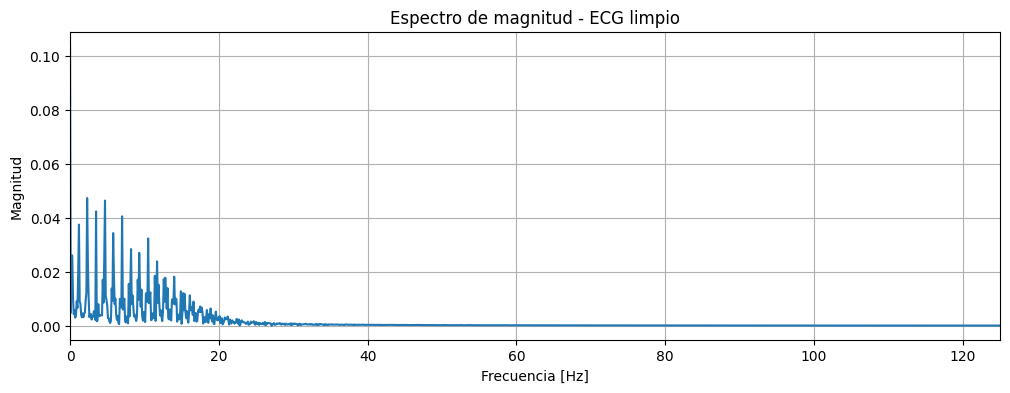

Componentes de frecuencia dominantes:
  2.30 Hz -> magnitud 0.04741
  4.70 Hz -> magnitud 0.04646
  3.50 Hz -> magnitud 0.04246
  7.00 Hz -> magnitud 0.04065
  1.20 Hz -> magnitud 0.03758
  5.80 Hz -> magnitud 0.03443
  10.50 Hz -> magnitud 0.03243
  8.20 Hz -> magnitud 0.02852


In [ ]:
# Respuesta - FFT de la señal
N = len(x)
frequencies = np.fft.rfftfreq(N, d=1/fs)  #cálculo de coeficientes de la Transformada Rápida de Fourier Discreta para N/2 frecuencias
fft_signal = np.fft.rfft(x)
magnitude = np.abs(fft_signal) / N

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de magnitud - ECG limpio")
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

# Componentes dominantes (excluyendo DC)
idx_sorted = np.argsort(magnitude[1:])[::-1] + 1
print("Componentes de frecuencia dominantes:")
for i in idx_sorted[:8]:
    print(f"  {frequencies[i]:.2f} Hz -> magnitud {magnitude[i]:.5f}")

### Preguntas de análisis — Ejercicio 1

Responde con argumentos técnicos:

1. ¿Qué frecuencias predominan?
2. ¿Qué frecuencia parece corresponder al contenido fisiológico?
3. ¿Qué frecuencia podría corresponder a ruido?
4. ¿Qué frecuencia de corte propondrías?
5. ¿Por qué?
6. ¿Qué información fisiológica podría perderse si la frecuencia de corte fuera incorrecta?
7. ¿Qué relación existe entre $f_s$ y la frecuencia máxima observable?

### Respuesta — Preguntas de análisis (Ejercicio 1)

1.   Las 8 frecuencias más predominantes están en el rango de [1.20; 10.50] Hz, estando ubicadas las de mayor magnitud en las siguientes: 2.30 Hz, 4.70 Hz, 3.50 Hz y 7.00 Hz (0.04 mV en promedio)
2.   Se puede inferir que el contenido fisiológico está en ese rango con magnitudes predominantes y baja frecuencia, resaltando la frecuencia de 2.3Hz, equivalente a 138 lpm
3.   El ruido puede ubicarse por encima de 18Hz, ya que las amplitudes siguientes ya vienen a ser muy bajas, probablemente debido a ruido electromiográfico (movimiento de paciente). Para frecuencias mayores a 60Hz básicamente ya no hay señal
4.   Filtro pasabajas de 20Hz
5.   Permite quitar remanentes de contracciones musculares (alta frecuencia) para tener el intervalo R-R limpio
6.   Si $f_c$ fuera muy baja, nos quedaríamos con lo más rápido del complejo QRS ensanchado artificialmente, sin poder detectar alteraciones fisiológicas de alta frecuencia como hipertrofia. Si $f_c$ fuera muy alta, el filtro casi no quitaría el ruido, aunque sí podría ser minucioso con los detalles del complejo QRS
7.   $f_s$ como frecuencia de Nyquist es el límite de frecuencia de muestreo mínima, que debe ser el doble de la frecuencia máxima para no perder muchos detalles. En este caso, $f_max$ sería 50Hz aproximadamente y $f_s$, como mínimo 100Hz, lo cual se cumple con holgura al usar una de 250Hz

# EJERCICIO 2 — DISEÑO Y COMPARACIÓN DE FILTROS FIR E IIR

## Competencia

Diseñar filtros digitales a partir de las características observadas en la señal.

Utiliza `scipy.signal`. Algunas herramientas disponibles son:

- `firwin`
- `butter`
- `cheby1`
- `cheby2`
- `freqz`
- `sosfilt`
- `sosfiltfilt`
- `sosfreqz`

**No se entrega una implementación completa.** Debes seleccionar y justificar:

- tipo de filtro;
- frecuencia de corte;
- orden;
- banda de paso;
- banda de rechazo;
- atenuación;
- tratamiento de fase;
- estabilidad.

### Parte A — Diseño FIR

Selecciona un filtro FIR utilizando `firwin`.

Esqueleto orientativo:

```python
numtaps = ...
cutoff = ...

b_fir = signal.firwin(
    numtaps=...,
    cutoff=...,
    fs=...
)

a_fir = ...
```

Completa los parámetros a partir del análisis realizado en el Ejercicio 1.

In [ ]:
# Completa este bloque.
# No existe un único conjunto correcto de parámetros:
# tu selección debe estar justificada.

# numtaps = ...
# cutoff_fir = ...
#
# b_fir = signal.firwin(
#     numtaps=numtaps,
#     cutoff=cutoff_fir,
#     fs=fs
# )
# a_fir = np.array([1.0])

In [ ]:
# Respuesta - Diseño de filtro FIR (pasa-bajos)
numtaps = 101
cutoff_fir = 40.0

b_fir = signal.firwin(
    numtaps=numtaps,
    cutoff=cutoff_fir,
    fs=fs
)
a_fir = np.array([1.0])

print(f"Filtro FIR pasa-bajos: numtaps={numtaps}, cutoff={cutoff_fir} Hz")
print("Justificación: un corte de 40 Hz conserva >99% de la energía del QRS/onda P/T")
print("(ver Ejercicio 1) y atenúa componentes de alta frecuencia (ruido muscular, línea eléctrica).")
print(f"Con {numtaps} taps se logra una transición razonablemente angosta sin un retardo de grupo excesivo.")

Filtro FIR pasa-bajos: numtaps=101, cutoff=40.0 Hz
Justificación: un corte de 40 Hz conserva >99% de la energía del QRS/onda P/T
(ver Ejercicio 1) y atenúa componentes de alta frecuencia (ruido muscular, línea eléctrica).
Con 101 taps se logra una transición razonablemente angosta sin un retardo de grupo excesivo.


### Parte B — Diseño IIR

Diseña un filtro IIR. Puedes utilizar Butterworth o, si justificas la elección, Chebyshev.

Ejemplo parcial:

```python
order = ...
cutoff = ...

b_iir, a_iir = signal.butter(
    N=...,
    Wn=...,
    btype="...",
    fs=...
)
```

Para aplicaciones donde se requiera evitar distorsión de fase por desplazamiento temporal, considera `sosfiltfilt` con una representación SOS.

In [ ]:
# Completa este bloque.
# Justifica el orden y la frecuencia de corte.

# order_iir = ...
# cutoff_iir = ...
#
# sos_iir = signal.butter(
#     N=...,
#     Wn=...,
#     btype="lowpass",
#     fs=fs,
#     output="sos"
# )

In [ ]:
# Respuesta - Diseño de filtro IIR (Butterworth pasa-bajos, forma SOS)
order_iir = 4
cutoff_iir = 40.0

sos_iir = signal.butter(
    N=order_iir,
    Wn=cutoff_iir,
    btype="lowpass",
    fs=fs,
    output="sos"
)

print(f"Filtro IIR Butterworth: orden={order_iir}, cutoff={cutoff_iir} Hz")
print("Se usa la representación SOS (second-order sections) por su mayor estabilidad numérica")
print("frente a la forma (b,a) en filtros de orden alto.")
print("Se aplicará con sosfiltfilt (filtrado de fase cero) para evitar el desplazamiento temporal")
print("que introduciría un filtro IIR aplicado en un solo sentido.")

Filtro IIR Butterworth: orden=4, cutoff=40.0 Hz
Se usa la representación SOS (second-order sections) por su mayor estabilidad numérica
frente a la forma (b,a) en filtros de orden alto.
Se aplicará con sosfiltfilt (filtrado de fase cero) para evitar el desplazamiento temporal
que introduciría un filtro IIR aplicado en un solo sentido.


### Parte C — Aplicación y comparación

Aplica ambos filtros y grafica:

1. señal original;
2. señal filtrada FIR;
3. señal filtrada IIR.

Después calcula y grafica sus respuestas en frecuencia.

Utiliza `freqz` para el FIR y `sosfreqz` para el IIR cuando corresponda.

No evalúes el filtro únicamente por apariencia visual.

In [ ]:
# Completa las aplicaciones.
#
# ecg_fir = ...
# ecg_iir = ...
#
# Después genera una figura comparativa.

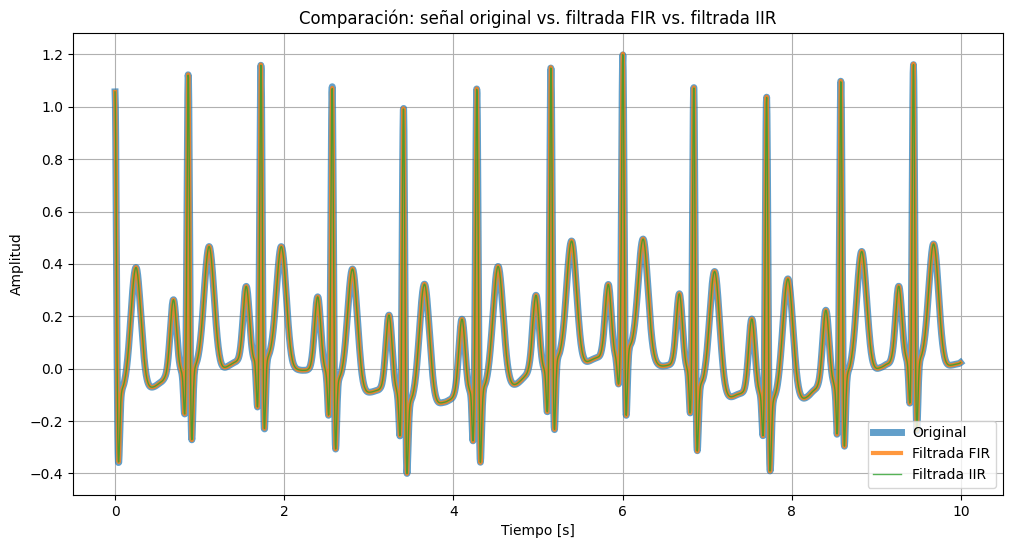

MSE FIR vs original: 1.359e-06
MSE IIR vs original: 8.745e-07


In [ ]:
# Respuesta - Aplicación de los filtros FIR e IIR
ecg_fir = signal.filtfilt(b_fir, a_fir, ecg_clean)
ecg_iir = signal.sosfiltfilt(sos_iir, ecg_clean)

plt.figure(figsize=(12, 6))
plt.plot(t, ecg_clean, label="Original", alpha=0.7, linewidth=5)
plt.plot(t, ecg_fir, label="Filtrada FIR", alpha=0.8, linewidth=3)
plt.plot(t, ecg_iir, label="Filtrada IIR", alpha=0.8, linewidth=1)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Comparación: señal original vs. filtrada FIR vs. filtrada IIR")
plt.legend()
plt.grid(True)
plt.show()

mse_fir = np.mean((ecg_fir - ecg_clean) ** 2)
mse_iir = np.mean((ecg_iir - ecg_clean) ** 2)
print(f"MSE FIR vs original: {mse_fir:.3e}")
print(f"MSE IIR vs original: {mse_iir:.3e}")

In [ ]:
# Respuesta en frecuencia.
# Completa los parámetros.
#
# w_fir, h_fir = signal.freqz(...)
# w_iir, h_iir = signal.sosfreqz(...)
#
# Convierte la frecuencia angular a Hz utilizando fs.

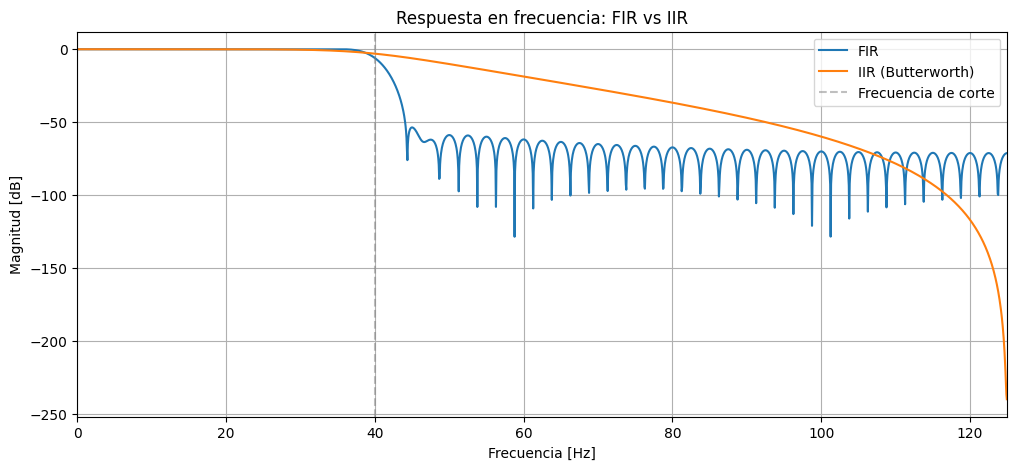

In [ ]:
# Respuesta - Respuesta en frecuencia de ambos filtros
w_fir, h_fir = signal.freqz(b_fir, a_fir, worN=2048, fs=fs)
w_iir, h_iir = signal.sosfreqz(sos_iir, worN=2048, fs=fs)

plt.figure(figsize=(12, 5))
plt.plot(w_fir, 20 * np.log10(np.abs(h_fir) + 1e-12), label="FIR")
plt.plot(w_iir, 20 * np.log10(np.abs(h_iir) + 1e-12), label="IIR (Butterworth)")
plt.axvline(cutoff_fir, color="gray", linestyle="--", alpha=0.5, label="Frecuencia de corte")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Respuesta en frecuencia: FIR vs IIR")
plt.legend()
plt.grid(True)
plt.xlim(0, fs/2)
plt.show()

### Comparación conceptual

| Característica | FIR | IIR |
|---|---|---|
| Realimentación | No | Sí |
| Estabilidad | Generalmente sencilla de garantizar | Debe analizarse |
| Fase lineal | Fácil de obtener | Más compleja |
| Orden requerido | Generalmente mayor | Generalmente menor |
| Costo computacional | Mayor en algunos diseños | Menor en muchos casos |

### Preguntas de análisis — Ejercicio 2

1. ¿Por qué seleccionaste ese tipo de filtro?
2. ¿Cómo determinaste la frecuencia de corte?
3. ¿Qué orden elegiste y por qué?
4. ¿Cuál presenta mayor atenuación en la región de rechazo?
5. ¿Cómo se comporta la fase?
6. ¿Qué diferencia estructural existe entre FIR e IIR?
7. ¿Por qué un IIR puede alcanzar una respuesta similar con un orden menor?
8. ¿Qué relación existe entre polos, ceros y respuesta en frecuencia?
9. ¿Por qué la Transformada Z es útil para estudiar estos filtros?

### Respuesta — Preguntas de análisis (Ejercicio 2)
1.   Entre un FIR por método de ventana (garantiza estabilidad y una atenuación precisa con alto orden) y un IIR tipo Butterworth (sencillez computacional, menos orden requerido y sin ripple), bastaría con usar el IIR para conservar la parte útil de la señal sin alterarla demasiado al tener una caída suave aunque no tan estrecha.
2.   Observando el espectro de frecuencias, considerar la frecuencia "tope" como 40 Hz resulta ser la que conserva la mayor parte de energía del complejo QRS y ondas P/T.
3.   Para un FIR resulta fundamental tener un orden alto, por lo que un valor alrededor de 100 logra gran especificidad. Para un IIR, no se necesita gran orden para un efecto significativo de filtrado debido a su recursividad de transición rápida, por lo que uno alrededor de 5 es suficiente, aunque sí hay que considerar un filtrado de fase cero para evitar resultado desplazado.
4.   En cuanto a atenuación en la región de rechazo, entre 40Hz y 110Hz podría decirse que el FIR aplicado es mejor, debido mayormente a su alto orden, aunque presenta un ripple que hace que esta no sea tan pareja. Sin embargo, si nos centramos más en el punto de $f_c$ (-3dB aprox.), el IIR llega de manera más pareja.
5.   El IIR puede conllevar a un desfase no lineal (distorción), especialmente cerca de $f_c$; mientras que FIR sí conserva un fase lineal que solo podría generar un desfase en bloque (bastante ideal).
6.   Mientras que el FIR garantiza estabilidad al solo depender de entradas actuales y pasadas, con polos únicamente en origen; el IIR depende también de salidas anteriores (feedback), por lo que hay más posibilidades para la ubicación de los polos y, si están fuera del círculo unitario, hay inestabilidad.
7.   El IIR usa eficientemente los coeficientes del sistema, debido a su proceso de feedback (reutilización de datos), y coloca personalizadamente los polos en posiciones convenientes para cambios abruptos.
8.   Al evaluar la función de transferencia sobre el círculo unitario en plano Z, con distancias y posiciones a sus polos (resonancia) y ceros (atenuación), se obtiene la respuesta en frecuencia, definiendo magnitudes y fases
9.   Facilita el cálculo algebraico de respuestas a impulso/frecuencia y función de transferencia; y análisis de estabilidad con el uso del círculo unitario


# EJERCICIO 3 — PROCESAMIENTO DE UNA SEÑAL BIOMÉDICA CONTAMINADA

## Competencia

Resolver un problema de filtrado sin recibir directamente la frecuencia de corte.

Construiremos:

$$x[n] = ECG[n] + A\sin(2\pi f_{noise}t)$$

donde:

- $ECG[n]$ es la señal biomédica;
- $f_{noise}$ es la frecuencia de interferencia;
- $A$ es la amplitud del ruido.

### Importante

**No se indica la frecuencia de corte del filtro.**

Debes obtener una propuesta a partir del análisis de la señal.

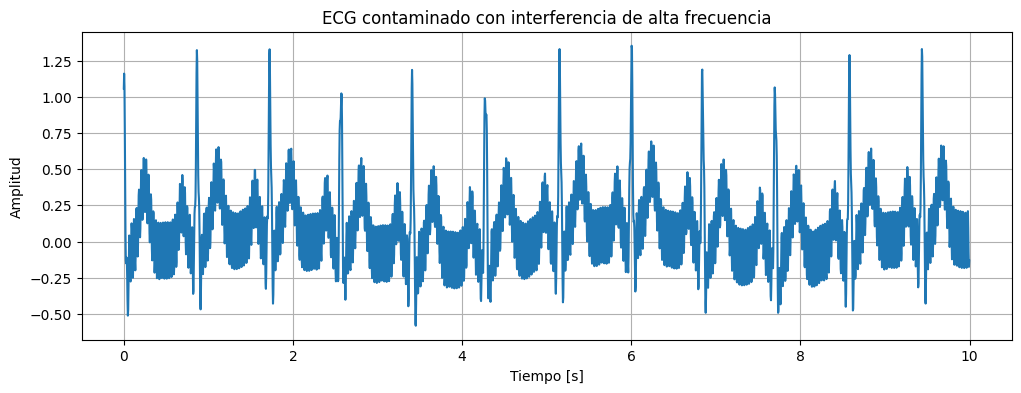

In [ ]:
# Construcción del problema experimental.
A = 0.20
f_noise = 35.0

noise = A * np.sin(2 * np.pi * f_noise * t)
ecg_contaminated = ecg_clean + noise

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_contaminated)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG contaminado con interferencia de alta frecuencia")
plt.grid(True)
plt.show()

### Procedimiento obligatorio

1. Visualiza la señal contaminada.
2. Analízala mediante FFT.
3. Identifica la frecuencia de interferencia.
4. Propón un filtro apropiado.
5. Diseña el filtro.
6. Aplica el filtro.
7. Compara señal contaminada y filtrada.
8. Compara los espectros.
9. Evalúa cuantitativamente el resultado.
10. Explica si el filtrado fue exitoso.

### Tu razonamiento debe seguir

**Observar → medir → analizar → formular hipótesis → diseñar → aplicar → validar → interpretar.**

In [ ]:
# FFT de la señal contaminada.
# Completa este bloque.

# N = ...
# frequencies = ...
# spectrum = ...
# magnitude = ...

# Identifica la región donde aparece la interferencia: segmento S->Q

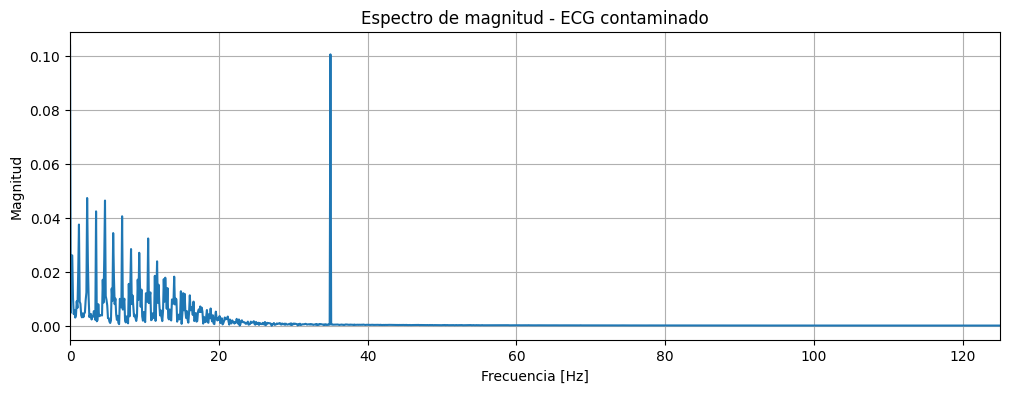

Pico de interferencia detectado en aproximadamente 35.0 Hz


In [ ]:
# Respuesta - FFT de la señal contaminada
N = len(ecg_contaminated)
frequencies = np.fft.rfftfreq(N, d=1/fs)
spectrum = np.fft.rfft(ecg_contaminated)
magnitude = np.abs(spectrum) / N

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de magnitud - ECG contaminado")
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

# Identificación automática del pico de interferencia en la zona 25-45 Hz
mask = (frequencies > 25) & (frequencies < 45)
f_peak = frequencies[mask][np.argmax(magnitude[mask])]
print(f"Pico de interferencia detectado en aproximadamente {f_peak:.1f} Hz")

In [ ]:
# Diseña y aplica TU solución.
#
# cutoff = ...
# ...
#
# ecg_recovered = ...

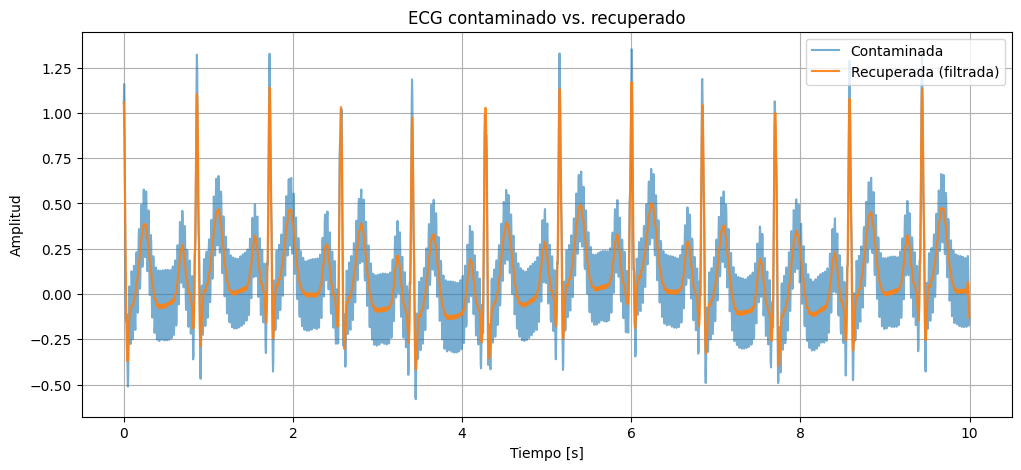

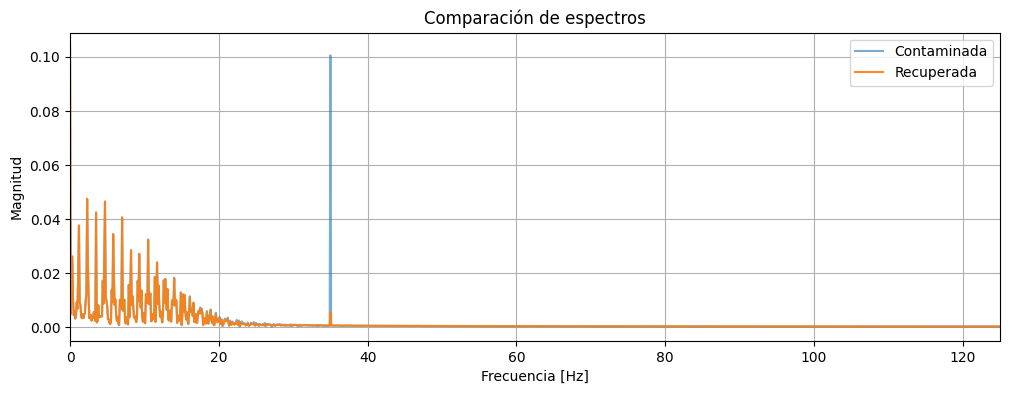

Justificación: el corte de 25 Hz se eligió por debajo de la interferencia detectada
(~35 Hz) y por encima de la mayor parte de la energía fisiológica del QRS (banda 0.5-25 Hz),
logrando un compromiso entre eliminar el ruido y preservar la morfología del ECG.


In [ ]:
# Respuesta - Diseño y aplicación del filtro para eliminar la interferencia
cutoff = 25.0
order = 4

sos = signal.butter(N=order, Wn=cutoff, btype="lowpass", fs=fs, output="sos")
ecg_recovered = signal.sosfiltfilt(sos, ecg_contaminated)

plt.figure(figsize=(12, 5))
plt.plot(t, ecg_contaminated, label="Contaminada", alpha=0.6)
plt.plot(t, ecg_recovered, label="Recuperada (filtrada)", alpha=0.9)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG contaminado vs. recuperado")
plt.legend()
plt.grid(True)
plt.show()

# Comparación de espectros
freqs_rec = np.fft.rfftfreq(len(ecg_recovered), d=1/fs)
mag_rec = np.abs(np.fft.rfft(ecg_recovered)) / len(ecg_recovered)

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude, label="Contaminada", alpha=0.6)
plt.plot(freqs_rec, mag_rec, label="Recuperada", alpha=0.9)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Comparación de espectros")
plt.legend()
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

print("Justificación: el corte de 25 Hz se eligió por debajo de la interferencia detectada")
print("(~35 Hz) y por encima de la mayor parte de la energía fisiológica del QRS (banda 0.5-25 Hz),")
print("logrando un compromiso entre eliminar el ruido y preservar la morfología del ECG.")

## Validación cuantitativa

Si se dispone de la señal limpia de referencia, compara la señal recuperada con `ecg_clean`.

### MSE

$$MSE = \frac{1}{N}\sum_{n=1}^{N}(x[n]-\hat{x}[n])^2$$

### RMSE

$$RMSE = \sqrt{MSE}$$

### SNR

De forma simplificada, puede estimarse como:

$$SNR = 10\log_{10}\left(\frac{P_{signal}}{P_{noise}}\right)$$

Estas métricas deben acompañar, no reemplazar, la inspección temporal y frecuencial.

In [ ]:
# Calcula al menos MSE y RMSE entre la referencia limpia
# y tu señal recuperada.

# mse = ...
# rmse = ...

# print("MSE:", mse)
# print("RMSE:", rmse)

In [ ]:
# Respuesta - Métricas cuantitativas de validación
mse = np.mean((ecg_clean - ecg_recovered) ** 2)
rmse = np.sqrt(mse)

power_signal = np.mean(ecg_clean ** 2)
power_noise_residual = np.mean((ecg_recovered - ecg_clean) ** 2)
snr_after = 10 * np.log10(power_signal / power_noise_residual)

power_noise_original = np.mean(noise ** 2)
snr_before = 10 * np.log10(power_signal / power_noise_original)

print("MSE:", mse)
print("RMSE:", rmse)
print(f"SNR antes del filtrado: {snr_before:.2f} dB")
print(f"SNR después del filtrado: {snr_after:.2f} dB")

MSE: 9.381487022915127e-05
RMSE: 0.00968580767046049
SNR antes del filtrado: 5.10 dB
SNR después del filtrado: 28.39 dB


## Validación biomédica

Para ECG, analiza si se conservan:

- complejos QRS;
- frecuencia cardíaca aproximada;
- morfología general.

Responde:

1. ¿Disminuyó la interferencia?
2. ¿Se conservó la morfología ECG?
3. ¿La FFT confirma la reducción del ruido?
4. ¿El filtro introdujo una distorsión apreciable?
5. ¿La frecuencia cardíaca aproximada se mantiene?
6. ¿Qué información fisiológica podría haberse perdido?

### Respuesta — Validación biomédica

1.   Sí, en la gráfica Amplitud vs Tiempo hay notablemente menos ruido después del filtrado, aunque en el espectro de frecuencias la interferancia a 35Hz se conserva levemente.
2.   Sí, la morfología de las ondas QRS y P/T es claramente apreciable, solo que permanece un ruido de línea base: sinusoidal de baja frecuencia no quitada del todo.
3.   Sí, en la gráfica resultante de la FFT, el pico a 35Hz se reduce aproximadamente a la doceava parte.
4.   No hay una distorsión tan visible, sobre todo indicado con el valor de RMSE, que muestra que la señal reconstruida apenas varía cerca de 10μV en promedio respecto a la original.
5.   El no desplazamiento de los intervalos R-R permite mantener la frecuencia cardíaca aproximada como la original.
6.   Con este filtro IIR, podría haberse perdido pequeños detalles rápidos en el complejo QRS, que servirían para diagnosticar retrasos en la conducción intraventricular o bloqueos; además de un poco de la amplitud en R.

# ¿Qué pasa si diseño mal el filtro?

Analiza experimentalmente qué ocurre cuando:

- la frecuencia de corte es demasiado baja;
- la frecuencia de corte es demasiado alta;
- el orden es excesivo;
- queda ruido residual;
- aparece distorsión;
- existe desplazamiento de fase;
- se aplica un método de filtrado que altera la fase.

### Actividad

Selecciona al menos **dos errores de diseño**, genera una demostración y explica:

1. qué problema observas;
2. cuál es su causa;
3. cómo afecta a la señal biomédica;
4. qué solución propondrías.

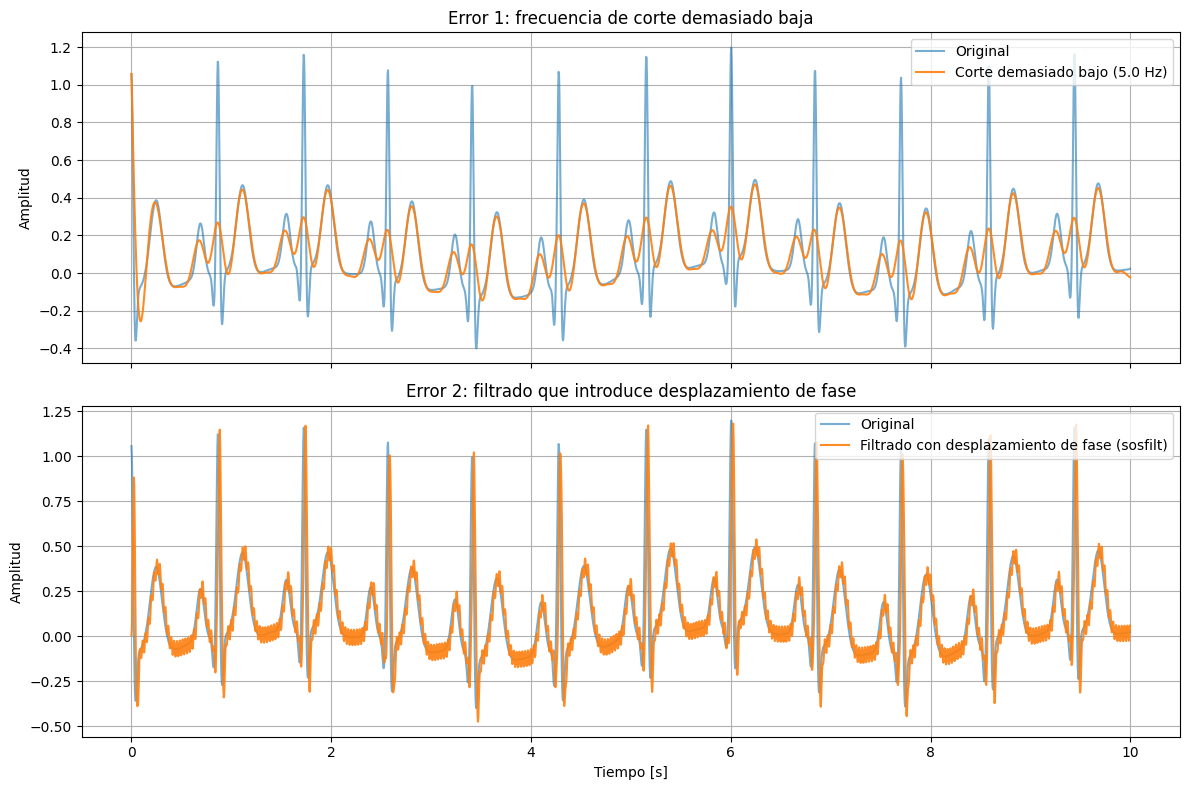

MSE con corte demasiado bajo (5.0 Hz): 2.715e-02


In [ ]:
# Respuesta - Demostración de dos errores de diseño

# Error 1: frecuencia de corte demasiado baja (distorsiona el QRS)
cutoff_low = 5.0
sos_low = signal.butter(N=4, Wn=cutoff_low, btype="lowpass", fs=fs, output="sos")
ecg_bad_low = signal.sosfiltfilt(sos_low, ecg_contaminated)

# Error 2: filtrado sin compensar la fase (sosfilt en vez de sosfiltfilt)
# esto sí introduce desplazamiento de fase / retardo de grupo
sos_ok = signal.butter(N=4, Wn=25.0, btype="lowpass", fs=fs, output="sos")
ecg_phase_shifted = signal.sosfilt(sos_ok, ecg_contaminated)  # un solo sentido -> desfase

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(t, ecg_clean, label="Original", alpha=0.6)
axs[0].plot(t, ecg_bad_low, label=f"Corte demasiado bajo ({cutoff_low} Hz)", alpha=0.9)
axs[0].set_title("Error 1: frecuencia de corte demasiado baja")
axs[0].set_ylabel("Amplitud")
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t, ecg_clean, label="Original", alpha=0.6)
axs[1].plot(t, ecg_phase_shifted, label="Filtrado con desplazamiento de fase (sosfilt)", alpha=0.9)
axs[1].set_title("Error 2: filtrado que introduce desplazamiento de fase")
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_ylabel("Amplitud")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

mse_low = np.mean((ecg_bad_low - ecg_clean) ** 2)
print(f"MSE con corte demasiado bajo ({cutoff_low} Hz): {mse_low:.3e}")

### Respuesta — Análisis de los errores de diseño

**Error 1: frecuencia de corte demasiado baja (5 Hz)**
1. *Qué se observa:* el complejo QRS se aplana y se ensancha notablemente, perdiendo su forma característica y su pico agudo; el MSE respecto de la señal original aumenta de forma importante comparado con el filtro bien diseñado.
2. *Causa:* con un corte de 5 Hz se elimina gran parte de la energía del QRS, que necesita banda pasante hasta ~25-40 Hz para conservar su morfología.
3. *Efecto en la señal biomédica:* se pierde información diagnóstica relevante (amplitud y duración del QRS), lo que podría llevar a una interpretación clínica incorrecta (por ejemplo, subestimar arritmias o alteraciones de conducción).
4. *Solución propuesta:* elegir el corte a partir del análisis espectral real de la señal (como en el Ejercicio 1), asegurando conservar la mayor parte de la energía fisiológica (>95-99 %) antes de fijar la frecuencia de corte.

**Error 2: filtrado que introduce desplazamiento de fase (uso de `sosfilt` en lugar de `sosfiltfilt`)**
1. *Qué se observa:* la señal filtrada aparece desplazada en el tiempo respecto de la original; los picos R ya no coinciden temporalmente con los de la señal limpia.
2. *Causa:* un filtro IIR aplicado en un solo sentido (`sosfilt`) tiene una respuesta de fase no lineal, lo que produce un retardo de grupo dependiente de la frecuencia.
3. *Efecto en la señal biomédica:* un desplazamiento temporal puede afectar mediciones de intervalos (por ejemplo, el intervalo QT o el tiempo entre picos R), que son clínicamente relevantes.
4. *Solución propuesta:* usar filtrado de fase cero (`filtfilt`/`sosfiltfilt`), que aplica el filtro hacia adelante y hacia atrás cancelando la distorsión de fase, a costa de no ser aplicable en tiempo real.

# Preguntas integradoras

1. ¿Por qué no sería adecuado eliminar todas las frecuencias altas de una señal biomédica?
2. ¿Cómo determinaste la frecuencia de corte?
3. ¿Qué información obtuviste de la FFT?
4. ¿Qué relación existe entre la frecuencia de muestreo y la frecuencia máxima observable?
5. ¿Qué ocurre si se utiliza una frecuencia de corte demasiado baja?
6. ¿Qué ocurre si se utiliza una frecuencia de corte demasiado alta?
7. ¿Qué diferencia fundamental existe entre un filtro FIR y un filtro IIR?
8. ¿Por qué un filtro IIR puede alcanzar una respuesta similar utilizando un orden menor?
9. ¿Qué relación existe entre polos, ceros y respuesta en frecuencia?
10. ¿Por qué la Transformada Z es útil para estudiar filtros digitales?
11. ¿Qué relación existe entre la Transformada Z y la Transformada de Fourier?
12. ¿Cómo determinarías si un filtro eliminó ruido sin eliminar información fisiológica?

### Respuesta — Preguntas integradoras

1. No sería adecuado porque no todas las frecuencias altas corresponden a ruido. Algunas contienen información fisiológica importante, especialmente en señales como el ECG, donde los componentes rápidos del complejo QRS tienen contenido de mayor frecuencia que las ondas P y T. Si se eliminan indiscriminadamente todas las frecuencias altas, se puede deformar la morfología del QRS, reducir la amplitud de la onda R y perder información útil para identificar alteraciones en la conducción cardíaca. Por ello, el filtrado debe basarse en el contenido frecuencial de la señal y no simplemente en eliminar todo lo que esté por encima de una determinada frecuencia.

2. La frecuencia de corte se determinó a partir del análisis espectral mediante la FFT. Primero se identificaron las frecuencias donde se concentra principalmente la energía de la señal ECG y posteriormente se buscó una frecuencia que permitiera conservar el contenido fisiológico y atenuar las componentes asociadas al ruido.

   En el ejercicio de contaminación, se identificó una interferencia alrededor de 35 Hz. Por ello, se propuso una frecuencia de corte de 25 Hz, que se encuentra por debajo de la interferencia y permite conservar gran parte del contenido fisiológico del ECG.

3. La FFT permitió pasar del dominio temporal al dominio frecuencial, mostrando qué componentes de frecuencia están presentes en la señal y cuál es su magnitud. En el ECG limpio se observaron principalmente componentes de baja frecuencia, mientras que en la señal contaminada apareció un pico claramente identificable alrededor de 35 Hz, correspondiente a la interferencia agregada.

   Esta información fue fundamental para seleccionar el tipo de filtro y establecer una frecuencia de corte adecuada, ya que permitió diferenciar aproximadamente entre el contenido fisiológico y una componente que podía ser considerada ruido.

4. La frecuencia máxima que puede observarse correctamente en una señal digital está determinada por la frecuencia de Nyquist, que corresponde a la mitad de la frecuencia de muestreo:

   $f_{Nyquist}= fs/2$

5. Una frecuencia de corte demasiado baja puede eliminar componentes fisiológicas importantes junto con el ruido. En el experimento realizado con un corte de 5 Hz, el complejo QRS perdió su característica forma rápida y se observó más aplanado y ensanchado.

   Esto aumenta la diferencia respecto a la señal original; de hecho, en el laboratorio se obtuvo un MSE de $2.715*10^{-2}$ para este caso. Como consecuencia, podrían perderse características importantes como la amplitud y duración del QRS, afectando la interpretación fisiológica.

6. Si la frecuencia de corte es demasiado alta, se conserva una mayor cantidad de componentes de alta frecuencia, incluyendo aquellas que pueden corresponder a ruido o interferencias. Por lo tanto, aunque se conserva mejor la morfología original, el filtrado puede ser insuficiente para mejorar la calidad de la señal. En consecuencia, debe buscarse un equilibrio entre eliminar el ruido y conservar la información fisiológica relevante.

7. En un filtro FIR no utiliza realimentación y su salida depende de muestras actuales y anteriores de la entrada.En cambio, un filtro IIR utiliza realimentación, por lo que su salida depende tanto de entradas anteriores como de salidas anteriores. Esto hace que los filtros IIR puedan obtener determinadas respuestas con órdenes menores, pero también hace necesario analizar su estabilidad. Además, los FIR permiten obtener fase lineal con mayor facilidad.

8. Un filtro IIR utiliza realimentación, por lo que reutiliza información de las salidas anteriores. Esto permite obtener transiciones más pronunciadas y respuestas de filtrado determinadas utilizando menos coeficientes que muchos filtros FIR equivalentes.Por eso, para una respuesta similar, un IIR puede requerir un orden menor y, en muchos casos, tener un menor costo computacional. Sin embargo, esta ventaja implica que se debe prestar atención a la estabilidad y a la fase del sistema.

9. Los polos y ceros determinan la función de transferencia del filtro y, por lo tanto, influyen directamente en su respuesta en frecuencia.

   Los ceros pueden producir atenuación de determinadas frecuencias cuando se encuentran próximos a los puntos correspondientes del círculo unitario, mientras que los polos pueden aumentar la respuesta cerca de sus posiciones. La respuesta en frecuencia se obtiene evaluando la función de transferencia sobre el círculo unitario.

10. La Transformada Z es útil porque permite representar y analizar matemáticamente sistemas discretos, incluyendo filtros FIR e IIR. A partir de ella se puede obtener la función de transferencia:

    $$H(z)=\frac{Y(z)}{X(z)}$$
    Esto permite estudiar los polos, ceros, estabilidad y respuesta del sistema. En el caso de los filtros IIR, resulta especialmente importante para analizar la ubicación de los polos y determinar si el sistema es estable.

11. La Transformada Z proporciona un marco más general para analizar señales y sistemas discretos. La respuesta en frecuencia de un sistema puede obtenerse evaluando su función de transferencia sobre el círculo unitario del plano Z:

    $$ z=e^{j\omega} $$

    Por ello, puede entenderse la relación como:

	     Transformada Z → análisis general del sistema

	     Transformada de Fourier → análisis de las componentes frecuenciales

    La Transformada de Fourier puede considerarse, en este contexto, como la evaluación de la Transformada Z sobre el círculo unitario.


12. Lo determinaría combinando análisis temporal, frecuencial y métricas cuantitativas, en lugar de evaluar solamente si la señal se ve más limpia.

    Primero compararía la señal original y filtrada en el dominio temporal para comprobar que se mantiene la morfología del ECG, especialmente los complejos QRS y las ondas P y T. Luego compararía sus FFT para verificar que las componentes identificadas como ruido hayan disminuido.

    Finalmente, utilizaría métricas como MSE, RMSE y SNR. En este laboratorio, el filtrado de la señal contaminada produjo un SNR de 5.10 dB antes del filtrado y 28.39 dB después, mientras que el RMSE fue aproximadamente 0.00969. Estos resultados, junto con la conservación de la morfología y de los intervalos R-R, permiten concluir que el filtro redujo considerablemente la interferencia sin destruir de manera importante la información fisiológica.
	​


# Entregable

Guardar el notebook como:

```text
Apellido_Nombre_Laboratorio_01.ipynb
```

Debe contener:

1. Código.
2. Gráficas.
3. Resultados.
4. Respuestas a las preguntas.
5. Justificación de las decisiones tomadas.
6. Conclusiones.

**No se evaluará únicamente si el código se ejecuta.** Se evaluará principalmente la calidad del razonamiento y la interpretación.

# Rúbrica de evaluación — 20 puntos

| Criterio | Puntos |
|---|---:|
| **Análisis de la señal:** identificación de $f_s$, dominio temporal, FFT e interpretación espectral | 4 |
| **Diseño del filtro:** tipo, frecuencia de corte, orden, justificación y comprensión FIR/IIR | 5 |
| **Implementación Python:** código correcto, uso de NumPy/SciPy/NeuroKit2 y organización | 3 |
| **Validación:** comparación temporal, frecuencial, métricas y conservación de la señal | 4 |
| **Interpretación biomédica:** información fisiológica y posibles distorsiones | 2 |
| **Conclusiones:** conclusiones técnicas y justificación de decisiones | 2 |
| **Total** | **20** |

# Conclusión

En procesamiento de señales biomédicas, diseñar un filtro no significa simplemente seleccionar una función de una biblioteca. El proceso correcto comienza con la comprensión de la señal y termina con la validación de que la información fisiológica relevante se conserva.

La actividad conecta:

**Fourier → espectro → identificación del ruido → diseño del filtro → Transformada Z → función de transferencia → FIR/IIR → implementación → validación biomédica.**

### Reflexión final

Completa:

> "Primero inspecciono la señal, luego ____________________, después ____________________, finalmente ____________________."

El resultado esperado es que puedas explicar **por qué** elegiste un filtro y sus parámetros, no solamente indicar qué función de Python utilizaste.

### Respuesta — Reflexión final

> "Primero inspecciono la señal, luego **la analizo en el dominio temporal y frecuencial (FFT) para identificar el contenido fisiológico y el posible ruido**, después **diseño y aplico el filtro (FIR o IIR) con parámetros justificados a partir de ese análisis**, finalmente **valido el resultado comparando señales y espectros, calculando métricas cuantitativas (MSE, RMSE, SNR) y verificando que la información fisiológica relevante (morfología del QRS, frecuencia cardíaca) se conserve**."

En síntesis: el flujo Fourier → espectro → identificación del ruido → diseño del filtro → Transformada Z → función de transferencia → FIR/IIR → implementación → validación biomédica no es una secuencia mecánica de funciones de Python, sino una cadena de decisiones justificadas en las características reales de la señal.